# RNA velocity and regulatory perturbation analysis with RegVelo

[RegVelo](https://github.com/theislab/regvelo) is a gene-regulatory-informed RNA velocity model that jointly models transcriptional regulation and RNA splicing dynamics at single-cell resolution. Classical RNA velocity methods infer state transitions from unspliced and spliced RNA dynamics, but they make limited use of TF regulons, prior GRNs, and regulatory perturbations. GRN inference alone, in contrast, often lacks expression dynamics and cellular time. RegVelo places these two sources of information in one generative dynamical framework: it constrains transcription rates with a prior GRN, then infers velocity, latent time, and perturbed vector fields through coupled ODEs.

<img src="https://github.com/theislab/regvelo/blob/main/docs/_static/img/overview_fig.png?raw=true" alt="RegVelo" width="600" />

The inputs for RegVelo are an AnnData object with spliced/unspliced moment layers, a prior GRN aligned to the gene space, and a TF/regulator list. The model learns splicing kinetics under regulatory-network constraints and exports a velocity layer, latent time, gene-level kinetic parameters, and a velocity field that can be passed to CellRank. A trained RegVelo model can also run in silico TF regulon blockade: downstream regulatory effects of a TF are removed to generate a perturbed velocity field, and CellRank can then compare baseline and perturbed fate probabilities to connect local regulatory changes with long-term fate shifts.

In OmicVerse, we keep RegVelo's upstream model semantics while returning the results to `adata` for a workflow consistent with other velocity methods. This tutorial uses the adata-first `ov.single.velocity(..., method="regvelo")` interface for velocity inference, and `ov.single.cellrank_fate()` plus `ov.pl.cell_fate()` for CellRank fate analysis and visualization. The example follows the official RegVelo zebrafish neural crest tutorial, but the workflow is organized in OmicVerse style: explicit example-data loading, RegVelo input preparation, velocity inference, streamplot visualization, CellRank fate analysis, and TF perturbation simulation.

References: the RegVelo [repository](https://github.com/theislab/regvelo) and [documentation](https://regvelo.readthedocs.io/en/latest/index.html).

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
import regvelo as rgv

ov.plot_set(font_path="Arial")

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load the official RegVelo example and preprocess it with OmicVerse

This tutorial still uses the upstream RegVelo zebrafish neural crest example, but separates example-data loading from RegVelo preprocessing: data are loaded directly from upstream `regvelo.datasets`, while OmicVerse handles neighbors/moments, RegVelo gene preprocessing, and GRN alignment after `adata` is available.

In [2]:
adata = rgv.datasets.zebrafish_nc()
prior_net = rgv.datasets.zebrafish_grn()

velo_prep = ov.single.Velo(adata)
prior_grn, regulators = velo_prep.prepare_regvelo(
    prior_net,
    n_neighbors=30,
    n_pcs=50,
    moment_backend="scvelo",
    prior_orientation="regulator_by_target",
)
adata = velo_prep.adata

print(adata)
print("Available layers:", list(adata.layers.keys())[:10])
print("Prior GRN shape:", prior_grn.shape)
print("TFs retained:", len(regulators))

  0%|          | 0.00/40.2M [00:00<?, ?B/s]

In Velo module, you should keep all genes' expression not normalized.
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 30
   Method: umap
   Metric: euclidean
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 697 cells with 30 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 1.9515s                                                 │
│  Shape:    697 x 8,012 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighb

    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


AnnData object with n_obs × n_vars = 697 × 1008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'cell_type_colors', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity'
    obsp: 'distances', 'connectivities'
Available layers: ['ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity']
Prior GRN shape: (1008, 1008)
TFs retained: 81


## Use the OmicVerse-prepared prior GRN

`Velo.prepare_regvelo()` writes the aligned prior network to `adata.uns["skeleton"]` and stores the retained regulator list in `adata.uns["regvelo_regulators"]`. The upstream prior loaded by the RegVelo zebrafish helper is in regulator-by-target orientation; OmicVerse stores the aligned `adata.uns["skeleton"]`, and `ov.single.velocity(..., method="regvelo")` handles the orientation expected by `REGVELOVI`.

In [3]:
prior_grn = adata.uns["skeleton"]
regulators = adata.uns["regvelo_regulators"]

print("Prior GRN shape:", prior_grn.shape)
print("Regulators:", len(regulators))

Prior GRN shape: (1008, 1008)
Regulators: 81


## Run RegVelo through `ov.single.velocity`

The RegVelo branch can be used as an adata-first velocity workflow: it trains the upstream model, exports `layers["velocity"]` to `layers["velo_regvelo"]`, optionally builds the velocity graph, projects velocities to UMAP, records parameters in `adata.uns["regvelo"]`, and keeps the model path for downstream perturbation analysis.

In [4]:
adata = ov.single.velocity(
    adata,
    method="regvelo",
    prior_grn=prior_grn,
    regulators=regulators,
    model_save_path="result/regvelo_zebrafish",
    model_overwrite=True,
    velocity_key="velo_regvelo",
    spliced_layer="Ms",
    unspliced_layer="Mu",
    n_samples=30,
    regvelo_kwargs={
        "soft_constraint": False,
    },
    train_kwargs={
        "max_epochs": 50,  # Use fewer epochs for the tutorial; increase for real analyses
    },
    compute_velocity_graph=True,
    compute_velocity_embedding=True,
    basis="umap",
    graph_kwargs={
        "xkey": "Ms",
    },
)

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In Velo module, you should keep all genes' expression not normalized.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


computing velocity graph (using 1/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velo_regvelo_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_regvelo_umap', embedded velocity vectors (adata.obsm)


## Visualize the RegVelo vector field

Here we read results directly from `adata` with OmicVerse plotting functions. `ov.pl.embedding()` draws the cellular embedding, and `ov.pl.add_streamplot()` overlays the velocity field stored in `adata.obsm["velo_regvelo_umap"]`.

In [5]:
adata.uns["regvelo"]

{'spliced_layer': 'Ms',
 'unspliced_layer': 'Mu',
 'n_samples': 30,
 'batch_size': 697,
 'velocity_key': 'velo_regvelo',
 'n_regulators': 81,
 'model_load_path': None,
 'model_save_path': 'result/regvelo_zebrafish',
 'model_overwrite': True,
 'reuse_regvelo_output': False,
 'reused_regvelo_output': False}

Text(0.5, 1.0, 'Velocity: RegVelo')

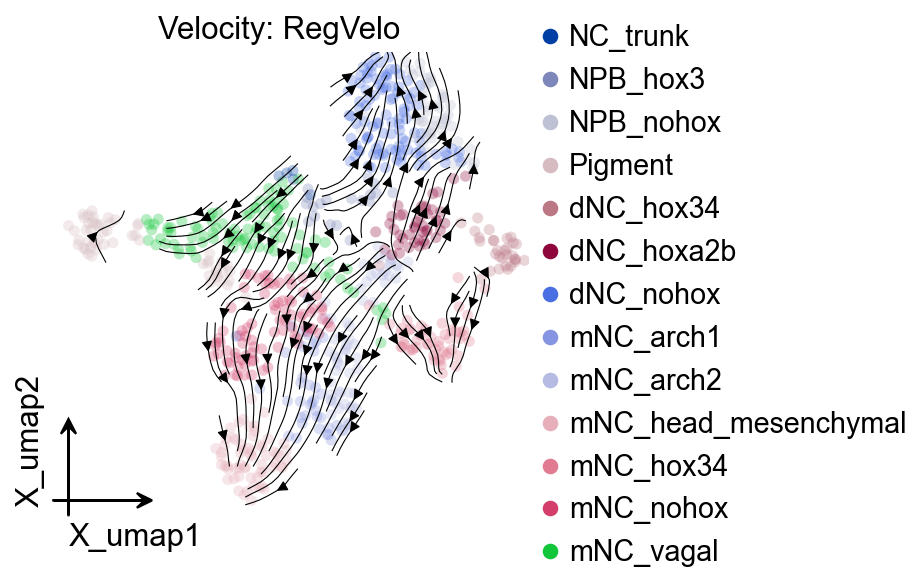

In [6]:
fig = ov.plt.figure(figsize=(4, 4))
ax = ov.plt.subplot(1, 1, 1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=ax,
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=ax,
)
ov.plt.title("Velocity: RegVelo")

## Check latent time and regulon size

This section inspects latent time and GRN structure. The exact diagnostic outputs can differ across RegVelo versions, so the cell first checks whether `fit_t` exists before plotting latent time, then summarizes prior regulon sizes from `adata.uns["skeleton"]`.

[<Axes: title={'center': 'cell_type'}, xlabel='X_umap1', ylabel='X_umap2'>,
 <Axes: title={'center': 'stage'}, xlabel='X_umap1', ylabel='X_umap2'>,
 <Axes: title={'center': 'regvelo_latent_time'}, xlabel='X_umap1', ylabel='X_umap2'>]

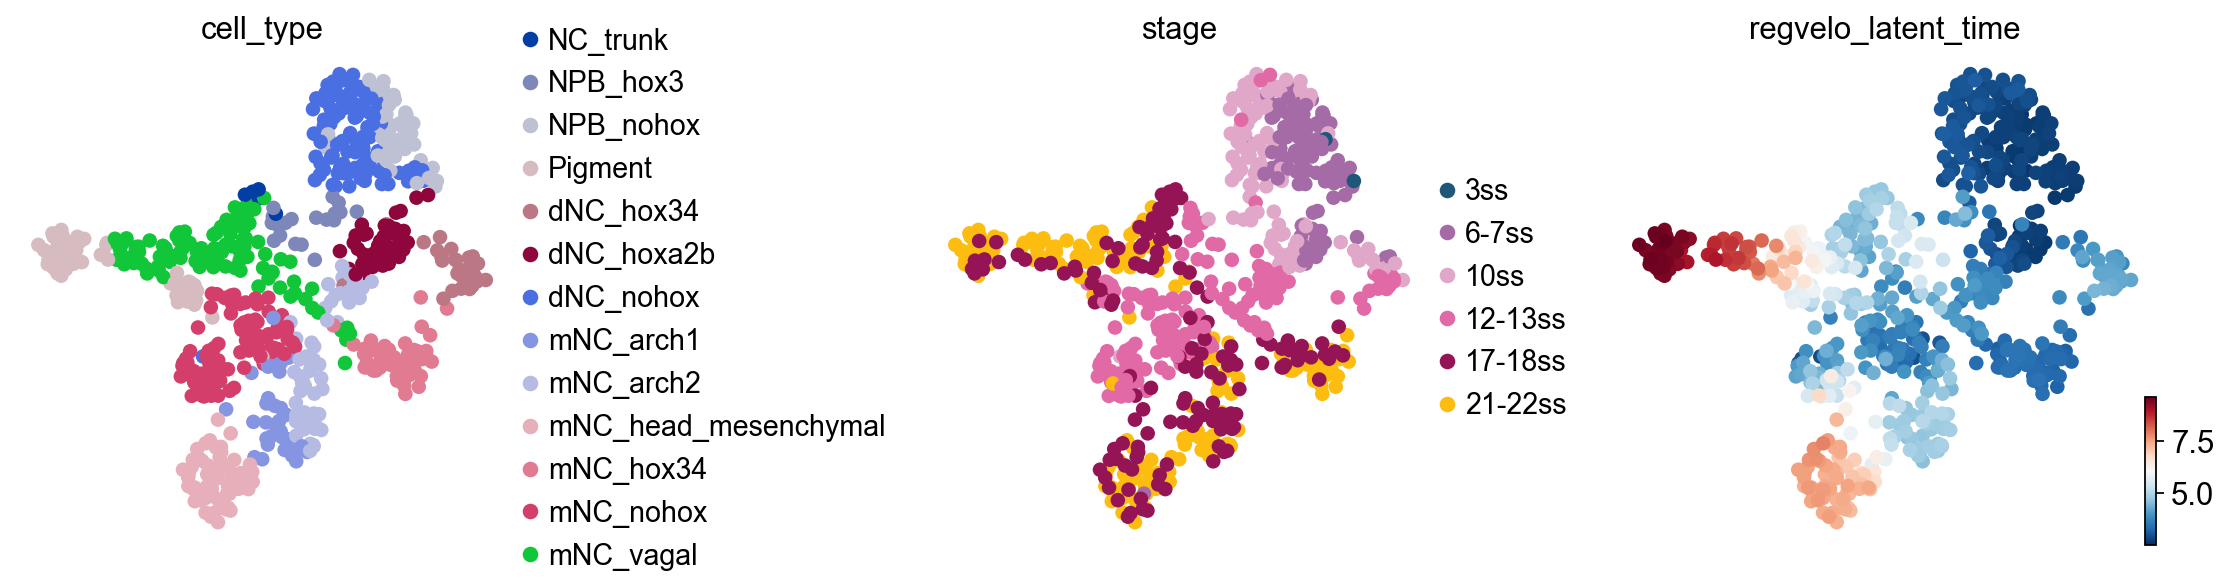

In [7]:
fit_t = np.asarray(adata.layers["fit_t"])
adata.obs["regvelo_latent_time"] = fit_t.mean(axis=1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=["cell_type", "stage", "regvelo_latent_time"],
    ncols=3,
    frameon=False,
    show=False,
)

Text(0.5, 1.0, 'Top prior regulons')

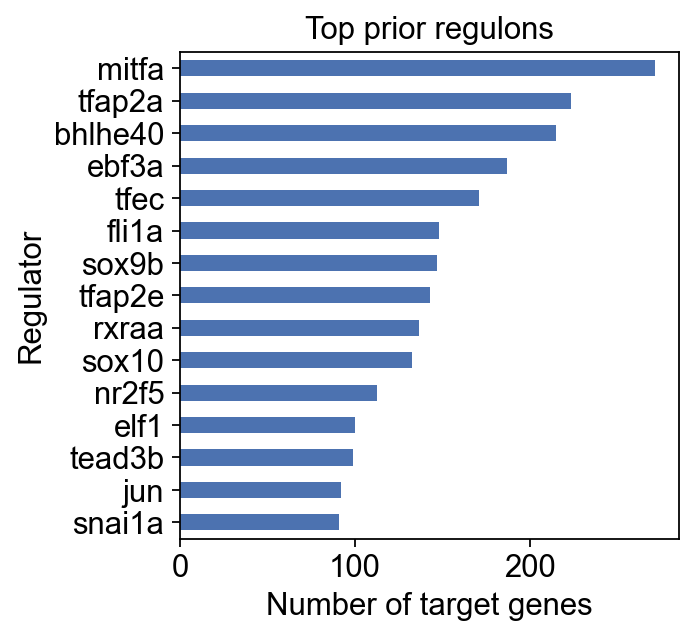

In [8]:
regulon_size = (prior_grn != 0).sum(axis=1).sort_values(ascending=False).head(15)
ax = regulon_size.sort_values().plot.barh(figsize=(4, 4), color="#4c72b0")
ax.set_xlabel("Number of target genes")
ax.set_ylabel("Regulator")
ax.set_title("Top prior regulons")

## CellRank fate analysis from RegVelo velocities

`ov.single.cellrank_fate()` builds a CellRank velocity kernel from `adata.layers["velo_regvelo"]`, optionally mixes in a connectivity kernel, computes GPCCA macrostates, and stores the estimator/kernel in `adata.uns["velocity_cellrank"]`.

In [9]:
terminal_states = ["mNC_head_mesenchymal", "mNC_hox34", "Pigment"]
terminal_states = [state for state in terminal_states if state in set(adata.obs["cell_type"])]
if not terminal_states:
    raise ValueError("None of the tutorial terminal states were found in adata.obs['cell_type'].")

estimator = ov.single.cellrank_fate(
    adata,
    velocity_key="velo_regvelo",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=7,
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    plot=False,
)


In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

Defaulting to `'gmres'` solver.


  0%|          | 0/3 [00:00<?, ?/s]

`ov.pl.cell_fate()` reuses the CellRank result stored in `adata.uns["velocity_cellrank"]["estimator"]`. It only visualizes the terminal states and does not recompute them.

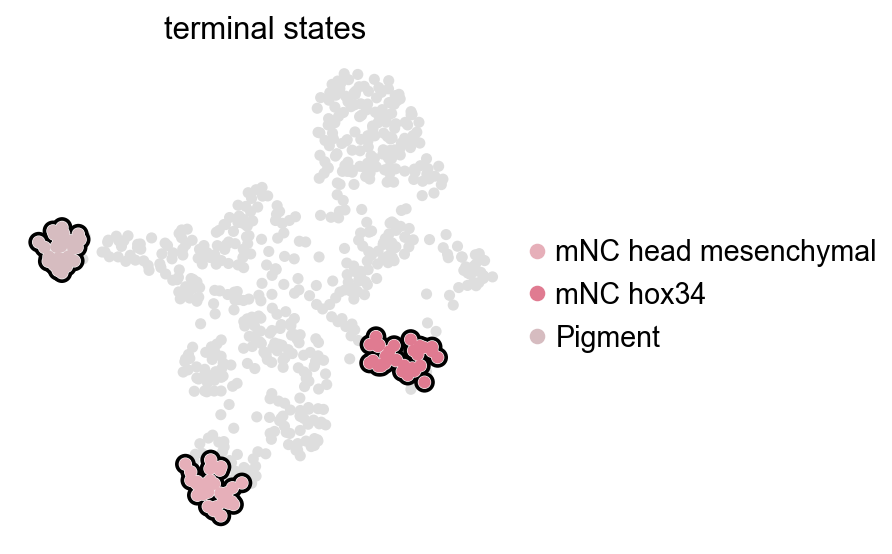

In [10]:
ov.pl.cell_fate(adata, which="terminal", basis="umap")

## Fate probabilities and commitment score

Beyond terminal-state dot plots, the official RegVelo perturbation tutorial also inspects CellRank fate probabilities and commitment scores. `commitment_score` is based on the entropy of the fate-probability distribution; lower values usually indicate more committed cell fates.

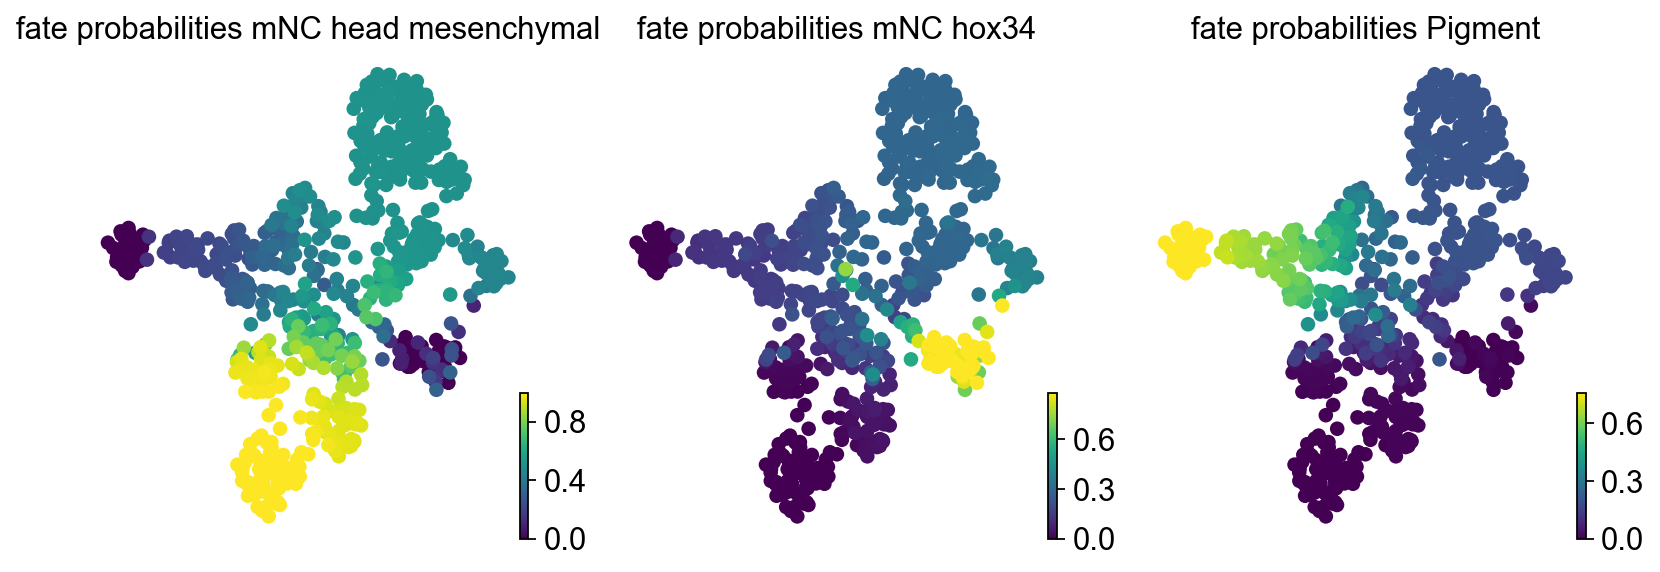

In [11]:
estimator.plot_fate_probabilities(
    same_plot=False,
    basis="umap",
)

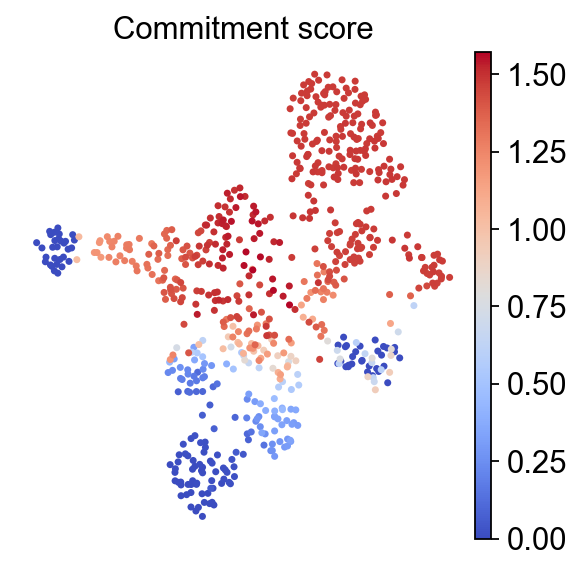

In [12]:
rgv.pl.commitment_score(
    adata=adata,
    lineage_key="lineages_fwd",
    frameon=False,
    s=40,
    cmap="coolwarm",
    title="Commitment score",
)

## Native RegVelo TF regulon blockade simulation

The reproducibility repository uses saved RegVelo models for TF perturbation and regulatory screening. Because `ov.single.velocity(method="regvelo")` has recorded the model path in `adata.uns["regvelo_model_path"]`, we create a lightweight `Velo` helper here to continue with the native RegVelo perturbation API.

In [13]:
velo_helper = ov.single.Velo(adata)
elf1_perturbed_adata, elf1_perturbed_model = velo_helper.regvelo_perturb(
    "elf1",
    model="result/regvelo_zebrafish",
    cutoff=0.001,
    batch_size=adata.n_obs,
)

print(elf1_perturbed_adata)

In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_zebrafish/model.pt already downloaded                                                 


AnnData object with n_obs × n_vars = 697 × 1008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage', 'velo_regvelo_self_transition', 'regvelo_latent_time', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'commitment_score'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_beta', 'fit_gamma', 'fit_scaling', 'velo_regvelo_genes'
    uns: 'cell_type_colors', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators', '_scvi_uuid', '_scvi_manager_uuid', 'regvelo_model_path', 'regvelo', 'velo_regvelo_graph', 'velo_regvelo_graph_neg', 'velo_regvelo_params', 'stage_colors_rgba', 'stage_colors', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_

In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 8/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


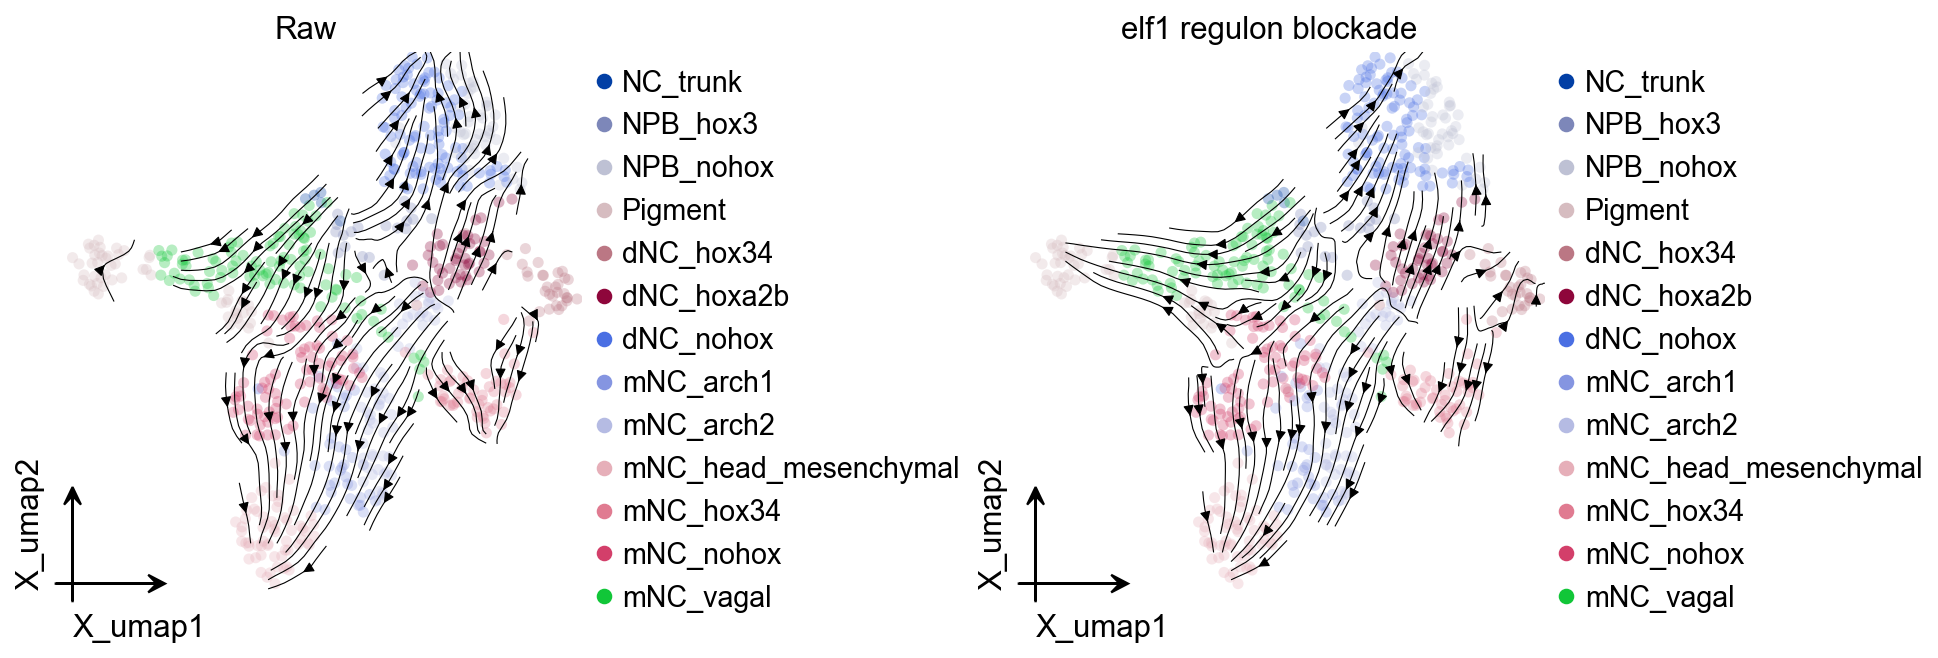

In [14]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

elf1_perturbed_velo = ov.single.Velo(elf1_perturbed_adata)
elf1_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=8)
elf1_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

ov.pl.embedding(
    elf1_perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    elf1_perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title("elf1 regulon blockade")

ov.plt.show()

## Quantify the effect of TF blockade

In addition to streamplot visualization, we can compare the baseline and perturbed velocity fields and CellRank fate probabilities.

Two complementary metrics are shown here:

- Local effect: velocity cosine dissimilarity for each cell. Larger values indicate stronger directional changes after perturbation.
- Fate effect: recompute CellRank fate probabilities on the perturbed velocity field and compare terminal-state probabilities before and after perturbation.

In [15]:
ov.single.velocity_effect(
    adata,
    elf1_perturbed_adata,
    baseline_velocity_key="velo_regvelo",
    perturbed_velocity_key="velocity",
    target="elf1",
)

velocity_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)["elf1_velocity_effect"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
velocity_effect_summary


In Velo module, you should keep all genes' expression not normalized.


                          mean    median       max
cell_type                                         
Pigment               0.000255  0.000308  0.000387
mNC_vagal             0.000142  0.000115  0.000287
mNC_arch2             0.000123  0.000121  0.000386
NPB_hox3              0.000121  0.000099  0.000327
dNC_hoxa2b            0.000106  0.000079  0.000335
mNC_arch1             0.000100  0.000084  0.000252
mNC_nohox             0.000098  0.000083  0.000333
NC_trunk              0.000093  0.000088  0.000121
mNC_hox34             0.000091  0.000088  0.000202
dNC_hox34             0.000091  0.000091  0.000166
mNC_head_mesenchymal  0.000076  0.000068  0.000149
NPB_nohox             0.000063  0.000058  0.000130
dNC_nohox             0.000060  0.000056  0.000123

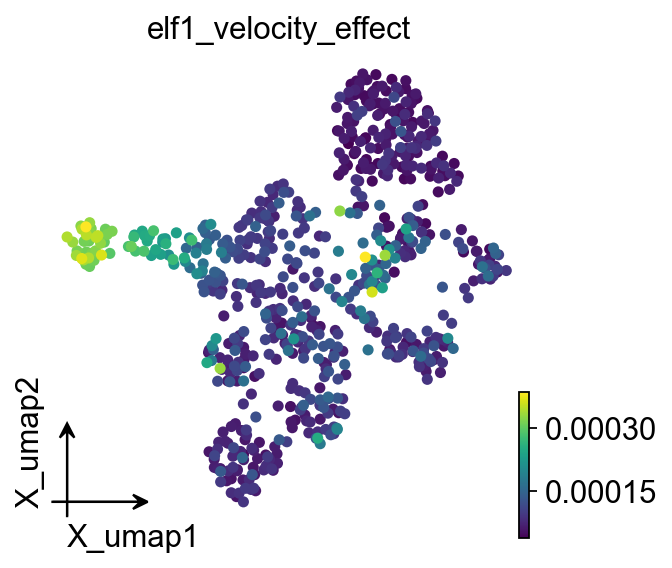

In [16]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color="elf1_velocity_effect",
    cmap="viridis",
    size=100,
)

In [17]:
elf1_estimator = ov.single.cellrank_fate(
    elf1_perturbed_adata,
    velocity_key="velocity",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=7,
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    plot=False,
)

In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/3 [00:00<?, ?/s]

In [18]:
import pandas as pd

def _lineage_to_df(adata_obj, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    values = np.asarray(lineages)
    names = getattr(lineages, "names", None)
    if names is None:
        names = [f"lineage_{i}" for i in range(values.shape[1])]
    return pd.DataFrame(values, index=adata_obj.obs_names, columns=list(names))

baseline_fate = _lineage_to_df(adata)
elf1_fate = _lineage_to_df(elf1_perturbed_adata)
common_fates = baseline_fate.columns.intersection(elf1_fate.columns)

elf1_fate_delta = elf1_fate[common_fates] - baseline_fate[common_fates]
elf1_fate_delta.columns = [f"elf1_delta_{state}" for state in common_fates]
adata.obs = adata.obs.join(elf1_fate_delta)

elf1_fate_delta_summary = elf1_fate_delta.groupby(adata.obs["cell_type"], observed=True).mean()
elf1_fate_delta_summary

                      elf1_delta_mNC_head_mesenchymal  elf1_delta_mNC_hox34  \
cell_type                                                                     
NC_trunk                                    -0.331760             -0.155969   
NPB_hox3                                    -0.310808             -0.110552   
NPB_nohox                                   -0.297561             -0.069342   
Pigment                                     -0.112662             -0.065701   
dNC_hox34                                   -0.234574             -0.103409   
dNC_hoxa2b                                  -0.293606             -0.063823   
dNC_nohox                                   -0.298146             -0.067176   
mNC_arch1                                    0.014600             -0.039512   
mNC_arch2                                   -0.014078             -0.068796   
mNC_head_mesenchymal                        -0.000056             -0.000325   
mNC_hox34                                    0.01697

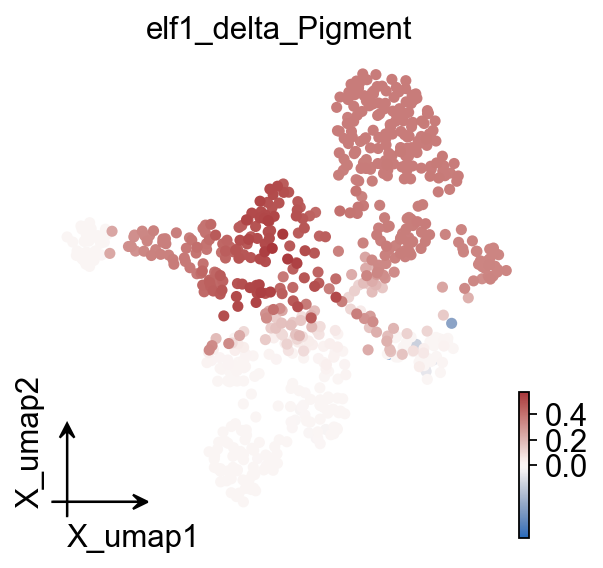

In [19]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color="elf1_delta_Pigment",
    cmap="vlag",
    vcenter=0,
    size=100,
)

RegVelo also provides a native fate-perturbation statistic that summarizes fate-probability depletion/enrichment after perturbation. Here `ov.single.cell_fate_perturbation()` provides a unified call; internally OmicVerse handles the `metrics` / `mt` namespace difference across RegVelo versions.

In [20]:
elf1_fate_stats = ov.single.cell_fate_perturbation(
    adata,
    perturbed={"elf1": elf1_perturbed_adata},
    terminal_states=terminal_states,
    score_method="likelihood",
)
elf1_fate_stats


In Velo module, you should keep all genes' expression not normalized.


   Depletion likelihood       p-value  FDR adjusted p-value  \
0              0.666427  2.696982e-27          8.090945e-27   
1              0.654652  7.812122e-24          1.171818e-23   
2              0.326490  1.000000e+00          1.000000e+00   

         Terminal state    TF  
0  mNC_head_mesenchymal  elf1  
1             mNC_hox34  elf1  
2               Pigment  elf1  

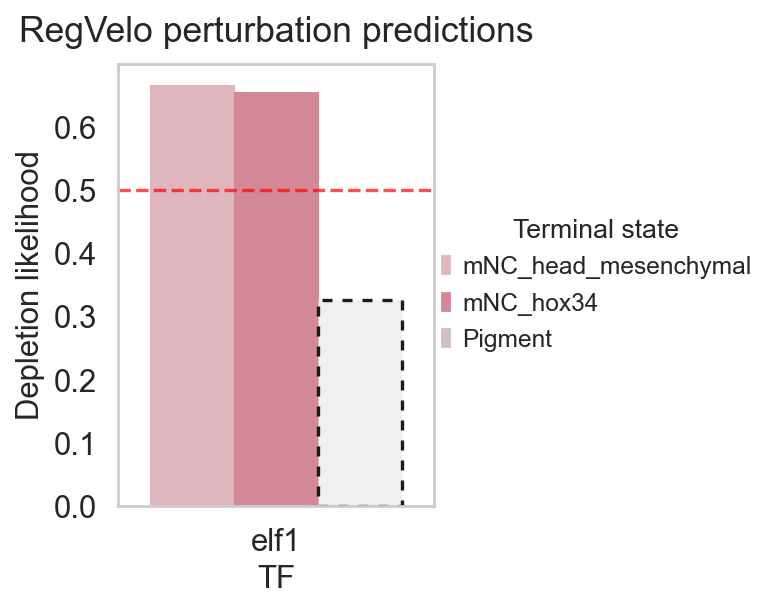

In [21]:
rgv.pl.cellfate_perturbation(
    adata=adata,
    df=elf1_fate_stats,
    color_label="cell_type",
    figsize=(5, 4),
)

## Single-cell perturbation effect

`ov.single.perturbation_effect()` writes the fate-probability difference between baseline and perturbation back to `adata.obs`. Negative values indicate that the probability of reaching a terminal fate decreases for that cell, while positive values indicate an increase.

In [22]:
adata = ov.single.perturbation_effect(
    adata,
    elf1_perturbed_adata,
    terminal_states=terminal_states,
)

effect_cols = [col for col in adata.obs.columns if col.startswith("perturbation effect on ")]
print(effect_cols)


In Velo module, you should keep all genes' expression not normalized.
['perturbation effect on mNC_head_mesenchymal', 'perturbation effect on mNC_hox34', 'perturbation effect on Pigment']


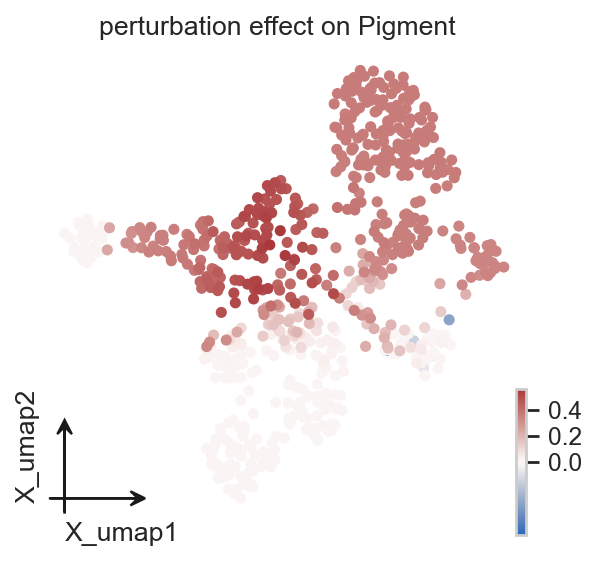

In [23]:
effect_key = "perturbation effect on Pigment"
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_key,
    cmap="vlag",
    vcenter=0,
    size=100,
)

## Multiple TF blockade

The `tf` argument of `regvelo_perturb()` can also receive multiple TFs. Multi-TF perturbation is useful for exploring combinatorial regulation, but it is best to first confirm that all selected TFs are retained in the regulator list of the current model.

In [24]:
multi_tfs = ["elf1", "nr2f5"]
multi_tfs = [tf for tf in multi_tfs if tf in adata.var_names]

multi_perturbed_adata, multi_perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    multi_tfs,
    model="result/regvelo_zebrafish",
    cutoff=0.001,
    batch_size=adata.n_obs,
)

multi_perturbed_velo = ov.single.Velo(multi_perturbed_adata)
multi_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=8)
multi_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_zebrafish/model.pt already downloaded                                                 


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 8/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


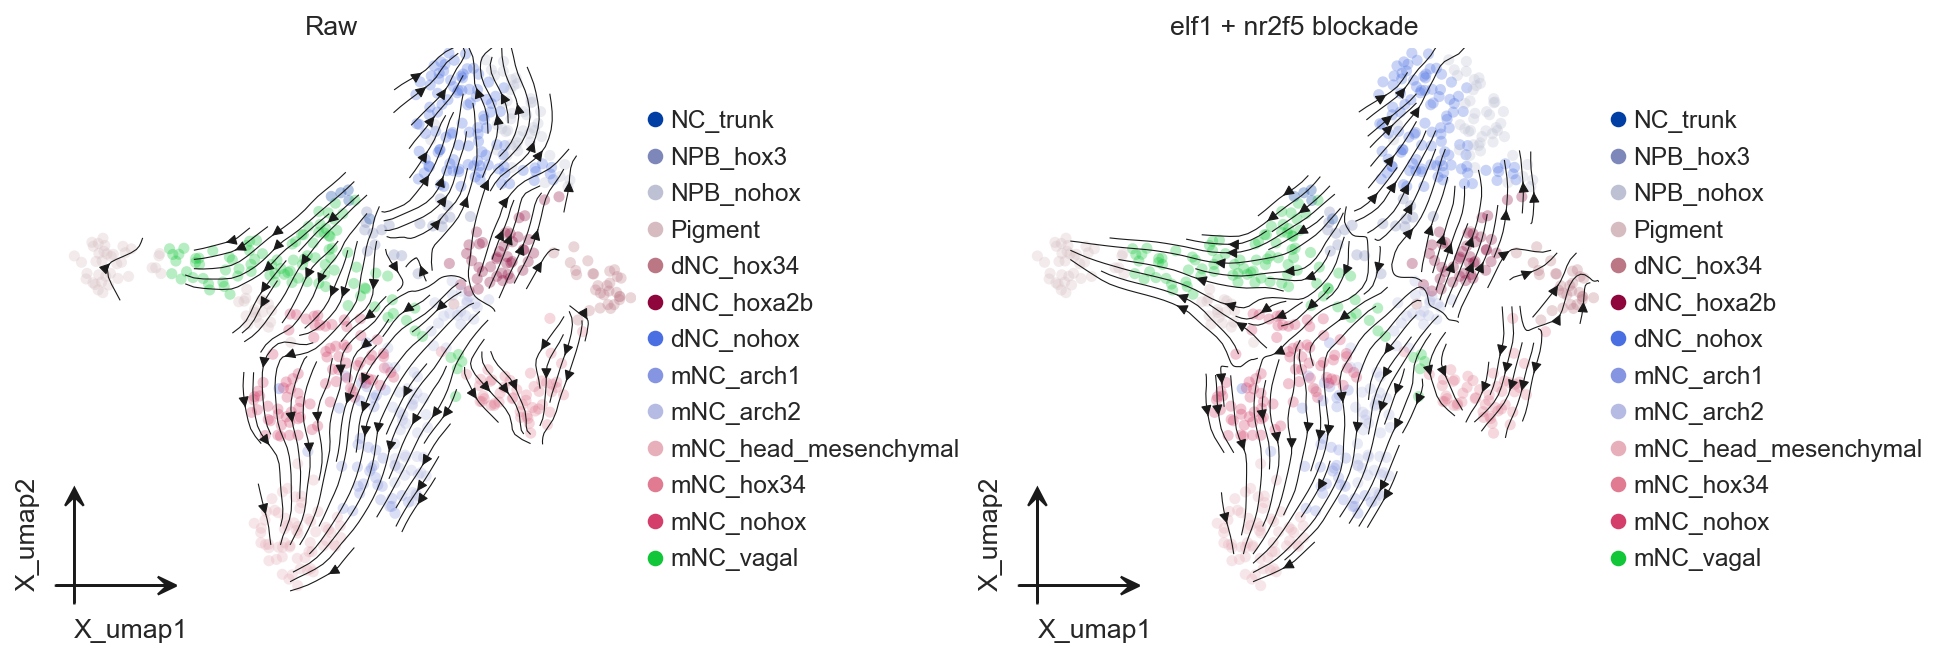

In [25]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

ov.pl.embedding(
    multi_perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    multi_perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title("elf1 + nr2f5 blockade")

ov.plt.show()